# Calibración de redes neuronales — Parte II

Este cuaderno está preparado para que el alumno tenga que programar poco.

Se incluyen:
- un modelo base sencillo,
- **Temperature Scaling**,
- **Focal Loss**,
- métricas de calibración,
- y una plantilla de experimentos.

El objetivo principal del alumno es **definir experimentos razonables, comparar configuraciones y analizar resultados**.

In [ ]:
# Instalación de dependencias
!pip install -q scikeras tensorflow scipy

## Preparando datos

### Dataset
Puedes cambiar fácilmente entre Fashion-MNIST y CIFAR10.
Para simplificar el modelo base, si el dataset tiene 3 canales se convierte a escala de grises.

TensorFlow: 2.20.0
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Train: (16914, 32, 32, 1) (16914,)
Val  : (10000, 32, 32, 1) (10000,)
Test : (10000, 32, 32, 1) (10000,)


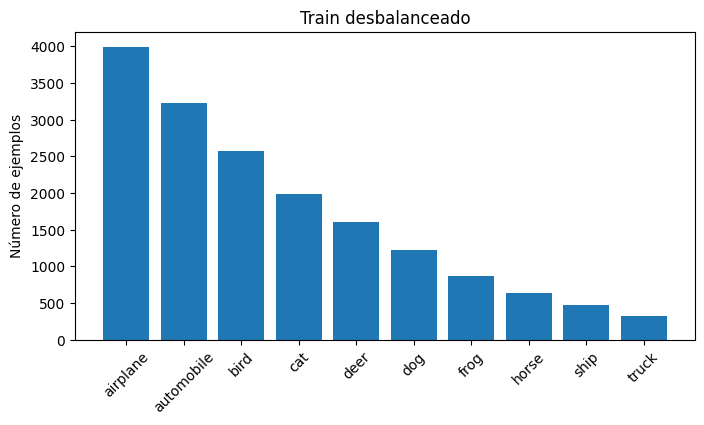

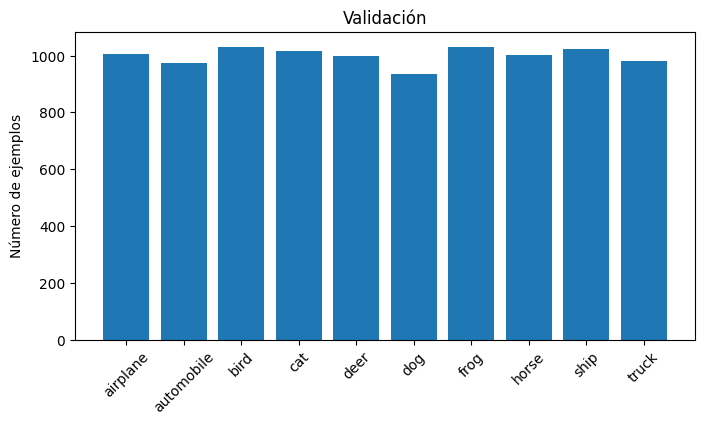

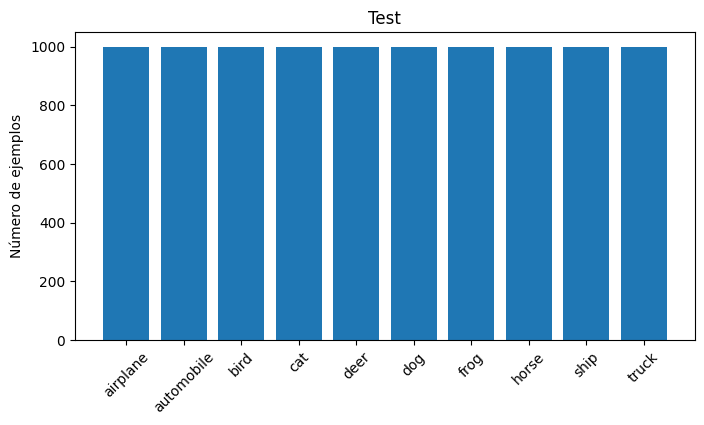

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy.optimize import minimize_scalar
from sklearn.metrics import accuracy_score

print("TensorFlow:", tf.__version__)

def make_imbalanced_train(X, y, keep_per_class, seed=42):
    rng = np.random.default_rng(seed)
    selected_idx = []

    for cls, keep_ratio in keep_per_class.items():
        cls_idx = np.where(y == cls)[0]
        n_keep = max(1, int(len(cls_idx) * keep_ratio))
        chosen = rng.choice(cls_idx, size=n_keep, replace=False)
        selected_idx.append(chosen)

    selected_idx = np.concatenate(selected_idx)
    rng.shuffle(selected_idx)

    return X[selected_idx], y[selected_idx]

def plot_class_distribution(y, class_names, title="Distribución de clases"):
    counts = np.bincount(y, minlength=len(class_names))
    plt.figure(figsize=(8, 4))
    plt.bar(range(len(class_names)), counts)
    plt.xticks(range(len(class_names)), class_names, rotation=45)
    plt.title(title)
    plt.ylabel("Número de ejemplos")
    plt.show()

# =========================
# Configuración del dataset
# =========================
USE_CIFAR10 = True  # Si lo pones a False, usarás el dataset FASHION_MNIST. Puedes cambiarlo si lo prefieres por cualquier otro.
USE_IMBALANCE = True

if USE_CIFAR10:
    datasetKeras = tf.keras.datasets.cifar10
    class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
else:
    datasetKeras = tf.keras.datasets.fashion_mnist
    class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']

(train_images, train_labels), (test_images, test_labels) = datasetKeras.load_data()

train_labels = train_labels.flatten()
test_labels = test_labels.flatten()

# Partición de validación a partir de train
rate_val = 0.2
n_val = int(len(train_images) * rate_val)

val_images = train_images[:n_val]
val_labels = train_labels[:n_val]
train_images = train_images[n_val:]
train_labels = train_labels[n_val:]

keep_per_class = {
    0: 1.00,
    1: 0.80,
    2: 0.65,
    3: 0.50,
    4: 0.40,
    5: 0.30,
    6: 0.22,
    7: 0.16,
    8: 0.12,
    9: 0.08,
}

if USE_IMBALANCE:
    train_images, train_labels = make_imbalanced_train(
        train_images, train_labels, keep_per_class, seed=200
    )

# Si las imágenes tienen 3 canales, se pasan a escala de grises para usar modelos sencillos
if len(train_images.shape) == 4 and train_images.shape[-1] == 3:
    train_images = tf.squeeze(tf.image.rgb_to_grayscale(train_images)).numpy()
    val_images   = tf.squeeze(tf.image.rgb_to_grayscale(val_images)).numpy()
    test_images  = tf.squeeze(tf.image.rgb_to_grayscale(test_images)).numpy()

# Normalización
train_images = train_images.astype("float32") / 255.0
val_images   = val_images.astype("float32") / 255.0
test_images  = test_images.astype("float32") / 255.0

# Añadir canal si el modelo es convolucional
if len(train_images.shape) == 3:
    train_images = np.expand_dims(train_images, axis=-1)
    val_images   = np.expand_dims(val_images, axis=-1)
    test_images  = np.expand_dims(test_images, axis=-1)

num_classes = len(class_names)
input_shape = train_images.shape[1:]

print("Train:", train_images.shape, train_labels.shape)
print("Val  :", val_images.shape, val_labels.shape)
print("Test :", test_images.shape, test_labels.shape)

plot_class_distribution(train_labels, class_names, title="Train desbalanceado")
plot_class_distribution(val_labels, class_names, title="Validación")
plot_class_distribution(test_labels, class_names, title="Test")

## Modelo base

Se deja una arquitectura sencilla pero suficiente para los experimentos.
La salida incluye una capa de logits y una softmax final.

In [ ]:
def create_base_model(input_shape, num_classes, loss="sparse_categorical_crossentropy"):
    inputs = tf.keras.layers.Input(shape=input_shape)

    x = tf.keras.layers.Conv2D(32, 3, activation='relu')(inputs)
    x = tf.keras.layers.MaxPooling2D(2)(x)
    x = tf.keras.layers.Dropout(0.10)(x)

    x = tf.keras.layers.Conv2D(64, 3, activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D(2)(x)
    x = tf.keras.layers.Dropout(0.10)(x)

    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    logits = tf.keras.layers.Dense(num_classes, name="logits")(x)
    outputs = tf.keras.layers.Activation("softmax", name="probs")(logits)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer="adam",
        loss=loss,
        metrics=["accuracy"]
    )
    return model

## Focal Loss

El alumno no tiene que implementarla; solo probar distintos valores de `gamma`.

In [ ]:
def sparse_focal_loss(gamma=2.0):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        y_true_onehot = tf.one_hot(y_true, depth=tf.shape(y_pred)[-1])
        pt = tf.reduce_sum(y_true_onehot * y_pred, axis=-1)
        loss = -tf.pow(1.0 - pt, gamma) * tf.math.log(pt)
        return tf.reduce_mean(loss)
    return loss_fn

## Funciones auxiliares de calibración

Incluye:
- accuracy
- NLL
- ECE
- diagrama de fiabilidad

In [ ]:
def predict_probs(model, X):
    return model.predict(X, verbose=0)

def accuracy_from_probs(y_true, probs):
    y_pred = np.argmax(probs, axis=1)
    return accuracy_score(y_true, y_pred)

def nll_from_probs(y_true, probs):
    probs = np.clip(probs, 1e-12, 1.0)
    return -np.mean(np.log(probs[np.arange(len(y_true)), y_true]))

def expected_calibration_error(y_true, probs, n_bins=10):
    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    accuracies = (predictions == y_true).astype(np.float32)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        left, right = bin_edges[i], bin_edges[i + 1]
        if i == n_bins - 1:
            mask = (confidences >= left) & (confidences <= right)
        else:
            mask = (confidences >= left) & (confidences < right)

        if np.any(mask):
            bin_acc = np.mean(accuracies[mask])
            bin_conf = np.mean(confidences[mask])
            ece += np.sum(mask) / len(y_true) * np.abs(bin_acc - bin_conf)

    return float(ece)

def reliability_diagram(y_true, probs, n_bins=10, title="Reliability diagram", ax=None):
    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    accuracies = (predictions == y_true).astype(np.float32)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0
    bin_width = 1.0 / n_bins

    bin_accs = []
    bin_confs = []
    bin_counts = []

    for i in range(n_bins):
        left, right = bin_edges[i], bin_edges[i + 1]
        if i == n_bins - 1:
            mask = (confidences >= left) & (confidences <= right)
        else:
            mask = (confidences >= left) & (confidences < right)

        if np.any(mask):
            bin_accs.append(np.mean(accuracies[mask]))
            bin_confs.append(np.mean(confidences[mask]))
            bin_counts.append(np.sum(mask))
        else:
            bin_accs.append(0.0)
            bin_confs.append(0.0)
            bin_counts.append(0)

    bin_accs = np.array(bin_accs)
    bin_confs = np.array(bin_confs)
    bin_counts = np.array(bin_counts)

    ece = np.sum((bin_counts / len(y_true)) * np.abs(bin_accs - bin_confs))

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5), dpi=120)

    # Diagonal ideal
    ax.plot([0, 1], [0, 1], '--', color='gray', label='Calibración perfecta')

    # Barras de accuracy por bin
    ax.bar(
        bin_centers,
        bin_accs,
        width=bin_width * 0.9,
        alpha=0.6,
        edgecolor='black',
        label='Accuracy por bin'
    )

    # Línea de confianza media observada
    valid = bin_counts > 0
    ax.plot(
        bin_centers[valid],
        bin_confs[valid],
        marker='o',
        linewidth=2,
        label='Confianza media'
    )

    # Gap entre confianza y accuracy
    for x, acc, conf, count in zip(bin_centers, bin_accs, bin_confs, bin_counts):
        if count > 0:
            ax.vlines(x, min(acc, conf), max(acc, conf), linestyles=':', linewidth=2)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Confianza")
    ax.set_ylabel("Acierto")
    ax.set_title(f"{title}\nECE = {ece:.4f}")
    ax.legend(loc="best")
    ax.grid(alpha=0.3)

    return ece

## Temperature Scaling

In [ ]:
def get_logits(model, X):
    logits_model = tf.keras.Model(inputs=model.input, outputs=model.get_layer("logits").output)
    return logits_model.predict(X, verbose=0)

def softmax_np(logits):
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exp_logits = np.exp(logits)
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

def apply_temperature_to_logits(logits, T):
    logits = logits.astype(np.float64)
    return softmax_np(logits / T)

def predict_tscaling(model, X, T):
    logits = get_logits(model, X)
    return apply_temperature_to_logits(logits, T)

def fit_temperature(model, X_val, y_val, bounds=(0.05, 10.0)):
    logits_val = get_logits(model, X_val)

    def objective(T):
        probs = apply_temperature_to_logits(logits_val, T)
        return nll_from_probs(y_val, probs)

    result = minimize_scalar(objective, bounds=bounds, method="bounded")
    return float(result.x), float(result.fun)

## Entrenamiento y evaluación

In [ ]:
def train_experiment(
    name,
    loss_name="ce",
    gamma=None,
    epochs=10,
    batch_size=128,
    seed=200
):
    tf.keras.utils.set_random_seed(seed)

    if loss_name == "ce":
        loss = "sparse_categorical_crossentropy"
    elif loss_name == "focal":
        loss = sparse_focal_loss(gamma=gamma)
    else:
        raise ValueError("loss_name debe ser 'ce' o 'focal'")

    model = create_base_model(input_shape, num_classes, loss=loss)
    history = model.fit(
        train_images, train_labels,
        validation_data=(val_images, val_labels),
        epochs=epochs,
        batch_size=batch_size,
        verbose=1
    )
    return model, history

def evaluate_probs(y_true, probs, prefix=""):
    return {
        f"{prefix}accuracy": accuracy_from_probs(y_true, probs),
        f"{prefix}nll": nll_from_probs(y_true, probs),
        f"{prefix}ece": expected_calibration_error(y_true, probs, n_bins=10),
    }

def evaluate_model(model, use_tscaling=False, T=None):
    probs_val = predict_probs(model, val_images)
    probs_test = predict_probs(model, test_images)

    out = {}
    out.update(evaluate_probs(val_labels, probs_val, prefix="val_"))
    out.update(evaluate_probs(test_labels, probs_test, prefix="test_"))

    if use_tscaling:
        if T is None:
            T, best_val_nll = fit_temperature(model, val_images, val_labels)
        else:
            best_val_nll = None

        probs_val_ts = predict_tscaling(model, val_images, T)
        probs_test_ts = predict_tscaling(model, test_images, T)

        out["temperature"] = T
        if best_val_nll is not None:
            out["val_nll_opt_temperature"] = best_val_nll

        out.update(evaluate_probs(val_labels, probs_val_ts, prefix="val_ts_"))
        out.update(evaluate_probs(test_labels, probs_test_ts, prefix="test_ts_"))

    return out

## Experimentos de ejemplo del profesor

### Entrenamiento con cross-entropy

In [ ]:
EPOCHS = 20
BATCH_SIZE = 128

# Modelo base con cross-entropy
model_ce, history_ce = train_experiment(
    name="CE",
    loss_name="ce",
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    seed=200
)

results_ce = evaluate_model(model_ce, use_tscaling=True)
results_ce

### Entrenamiento con focal loss

In [ ]:
model_focal_1_NO_TS, history_focal_1 = train_experiment(
    name="Focal gamma=1 (con TS)",
    loss_name="focal",
    gamma=1.0,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    seed=200
)
results_focal_1_NO_TS = evaluate_model(model_focal_1_NO_TS, use_tscaling=False)

model_focal_1_TS, history_focal_1_TS = train_experiment(
    name="Focal gamma=1 (sin TS)",
    loss_name="focal",
    gamma=1.0,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    seed=200
)
results_focal_1_TS = evaluate_model(model_focal_1_TS, use_tscaling=True)

results_focal_1_NO_TS
results_focal_1_TS

Epoch 1/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 23s 162ms/step - accuracy: 0.3699 - loss: 1.5447 - val_accuracy: 0.2669 - val_loss: 1.6991
Epoch 2/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 23s 174ms/step - accuracy: 0.4775 - loss: 1.2184 - val_accuracy: 0.3696 - val_loss: 1.4712
Epoch 3/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 39s 159ms/step - accuracy: 0.5263 - loss: 1.0813 - val_accuracy: 0.4148 - val_loss: 1.3262
Epoch 4/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 20s 153ms/step - accuracy: 0.5604 - loss: 0.9949 - val_accuracy: 0.4443 - val_loss: 1.2580
Epoch 5/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 21s 161ms/step - accuracy: 0.5821 - loss: 0.9308 - val_accuracy: 0.4681 - val_loss: 1.2082
Epoch 6/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 41s 163ms/step - accuracy: 0.6010 - loss: 0.8863 - val_accuracy: 0.4822 - val_loss: 1.1746
Epoch 7/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 21s 158ms/step - accuracy: 0.6210 - loss: 0.8417 - val_accuracy: 0.5045 - val_loss: 1.1423
Epoch 8/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 20s 151ms/step - accuracy: 0.6375 - loss: 0

{'val_accuracy': 0.5327,
 'val_nll': np.float32(1.4174614),
 'val_ece': 0.09937528145164254,
 'test_accuracy': 0.5292,
 'test_nll': np.float32(1.4284719),
 'test_ece': 0.10282911154329777,
 'temperature': 1.4550441981253661,
 'val_nll_opt_temperature': 1.345592444121162,
 'val_ts_accuracy': 0.5327,
 'val_ts_nll': np.float64(1.345592444121162),
 'val_ts_ece': 0.021269190402385982,
 'test_ts_accuracy': 0.5292,
 'test_ts_nll': np.float64(1.3536143174747324),
 'test_ts_ece': 0.017484159264112523}

## Resultados

### Tabla resumen

In [ ]:
# Tabla resumen de ejemplo
summary_df = pd.DataFrame([
    {
        "modelo":       "Cross-Entropy",
        "calibracion":  "Sin TS",
        "accuracy":     results_ce["test_accuracy"],
        "nll":          results_ce["test_nll"],
        "ece":          results_ce["test_ece"],
        "temperature":  np.nan,
    },
    {
        "modelo":       "Cross-Entropy",
        "calibracion":  "Con TS",
        "accuracy":     results_ce["test_ts_accuracy"],
        "nll":          results_ce["test_ts_nll"],
        "ece":          results_ce["test_ts_ece"],
        "temperature":  results_ce["temperature"],
    },
    {
        "modelo":       "Focal gamma=1",
        "calibracion":  "Sin TS",
        "accuracy":     results_focal_1_NO_TS["test_accuracy"],
        "nll":          results_focal_1_NO_TS["test_nll"],
        "ece":          results_focal_1_NO_TS["test_ece"],
        "temperature":  np.nan,
    },
    {
        "modelo":       "Focal gamma=1",
        "calibracion":  "Con TS",
        "accuracy":     results_focal_1_TS["test_ts_accuracy"],
        "nll":          results_focal_1_TS["test_ts_nll"],
        "ece":          results_focal_1_TS["test_ts_ece"],
        "temperature":  results_focal_1_TS["temperature"],
    },
])

summary_df

,modelo,calibracion,accuracy,nll,ece,temperature
0,Cross-Entropy,Sin TS,0.5237,1.557825,0.171294,NaN
1,Cross-Entropy,Con TS,0.5237,1.365477,0.022431,1.797334
2,Focal gamma=1,Sin TS,0.5292,1.428472,0.102829,NaN
3,Focal gamma=1,Con TS,0.5292,1.353614,0.017484,1.455044


### Gráficas fiabilidad T-Scaling

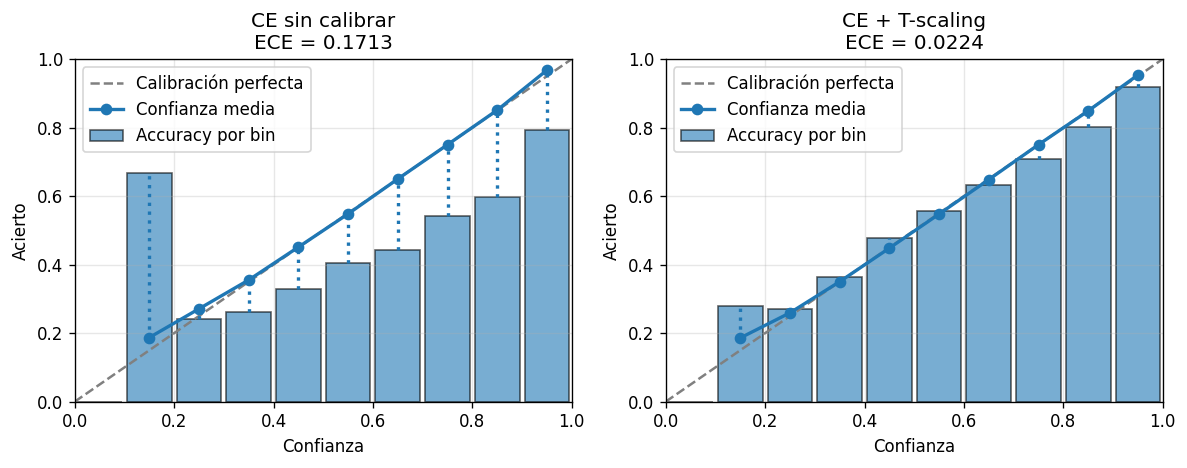

In [ ]:
# Diagramas de fiabilidad de ejemplo
fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=120)

probs_ce = predict_probs        (model_ce, test_images)
probs_ce_ts = predict_tscaling  (model_ce, test_images, results_ce["temperature"])

reliability_diagram(test_labels, probs_ce, title="CE sin calibrar", ax=axes[0])
reliability_diagram(test_labels, probs_ce_ts, title="CE + T-scaling", ax=axes[1])
plt.tight_layout()
plt.show()

### Gráficas fiabilidad Focal Loss

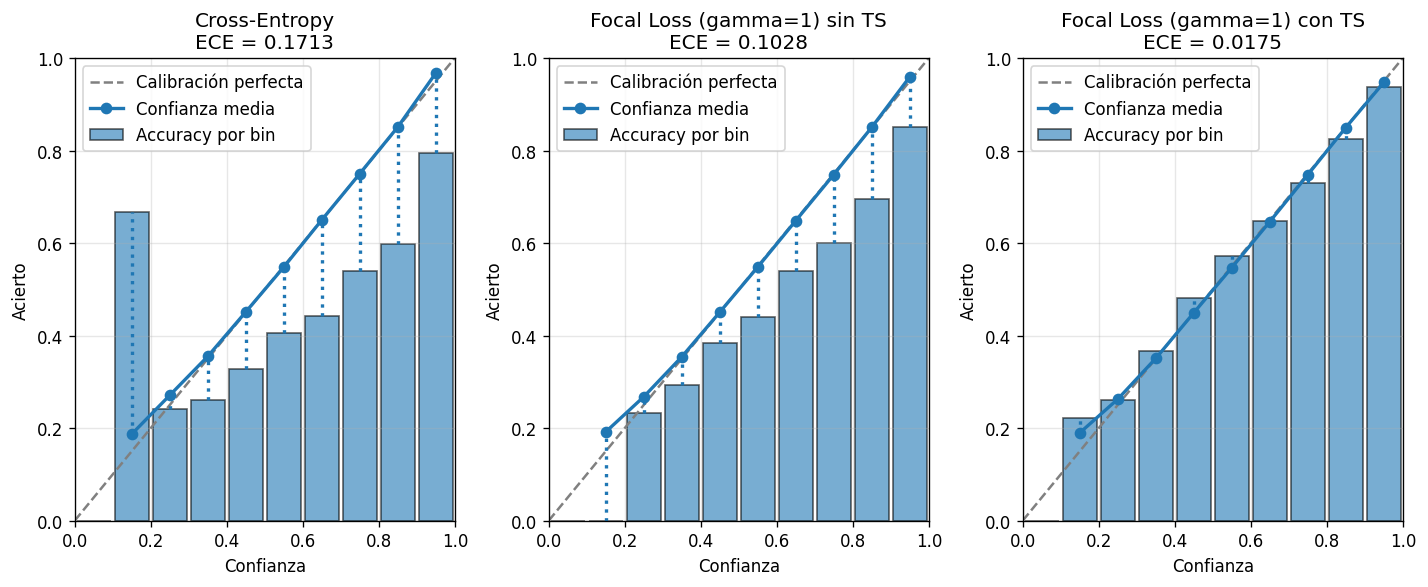

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5), dpi=120)

probs_ce = predict_probs(model_ce, test_images)
probs_focal_1_NO_TS = predict_probs   (model_focal_1_NO_TS, test_images)
probs_focal_1_TS = predict_tscaling   (model_focal_1_TS,    test_images, results_focal_1_TS["temperature"])

reliability_diagram(test_labels, probs_ce,            n_bins=10, title="Cross-Entropy",               ax=axes[0])
reliability_diagram(test_labels, probs_focal_1_NO_TS, n_bins=10, title="Focal Loss (gamma=1) sin TS", ax=axes[1])
reliability_diagram(test_labels, probs_focal_1_TS,    n_bins=10, title="Focal Loss (gamma=1) con TS", ax=axes[2])

plt.tight_layout()
plt.show()

#Implementación del alumno

En este apartado implementarás tus experimentos. Puedes basarte en el código proporcionado por el profesor. Puedes utilizar las funciones que ya hay implementadas o crearte propias en base a ese código.

## Estudio 1

Epoch 1/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 33s 213ms/step - accuracy: 0.3679 - loss: 1.8113 - val_accuracy: 0.2637 - val_loss: 1.9872
Epoch 2/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 21s 162ms/step - accuracy: 0.4743 - loss: 1.4921 - val_accuracy: 0.3477 - val_loss: 1.7919
Epoch 3/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 40s 157ms/step - accuracy: 0.5243 - loss: 1.3529 - val_accuracy: 0.3914 - val_loss: 1.6560
Epoch 4/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 44s 178ms/step - accuracy: 0.5620 - loss: 1.2575 - val_accuracy: 0.4234 - val_loss: 1.5799
Epoch 5/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 20s 151ms/step - accuracy: 0.5835 - loss: 1.1831 - val_accuracy: 0.4465 - val_loss: 1.5271
Epoch 6/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 21s 161ms/step - accuracy: 0.6049 - loss: 1.1333 - val_accuracy: 0.4706 - val_loss: 1.4674
Epoch 7/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 40s 151ms/step - accuracy: 0.6208 - loss: 1.0825 - val_accuracy: 0.4985 - val_loss: 1.4107
Epoch 8/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 21s 159ms/step - accuracy: 0.6351 - loss: 1

<Figure size 600x600 with 0 Axes>

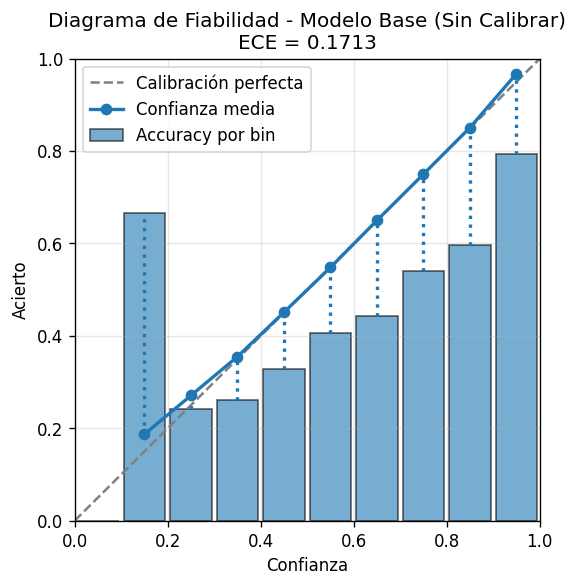

In [ ]:
#Aquí implementas tu código

EPOCHS = 20
BATCH_SIZE = 128

### Estudio 1.
# Primero entrenamos el modelo sin calibrar:

model_base, history_base = train_experiment(
    name="Modelo Base CE",
    loss_name="ce",
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

# Evaluamos el modelo sin calibrar:

# Predecimos probabilidades en test
probs_test_base = predict_probs(model_base, test_images)

# Calculamos métricas iniciales
metrics_base = evaluate_probs(test_labels, probs_test_base, prefix="base_test_")
print(f"Base Test Accuracy: {metrics_base['base_test_accuracy']:.4f}")
print(f"Base Test ECE: {metrics_base['base_test_ece']:.4f}")

# Dibujamos el diagrama de fiabilidad
plt.figure(figsize=(6,6))
reliability_diagram(test_labels, probs_test_base, title="Diagrama de Fiabilidad - Modelo Base (Sin Calibrar)")
plt.show()

Temperatura óptima encontrada: 1.7973
Calibrado Test Accuracy: 0.5237
Calibrado Test ECE: 0.0224


<Figure size 600x600 with 0 Axes>

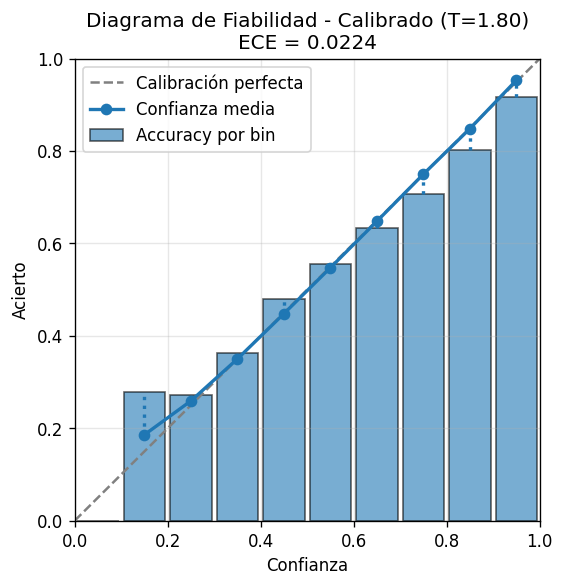

In [ ]:
# Ahora ajustamos el parámetro T, a partir del conjunto de validación:

# La función fit_temperature busca la T que minimiza el NLL en validación
T_base, nll_val = fit_temperature(model_base, val_images, val_labels)

print(f"Temperatura óptima encontrada: {T_base:.4f}")

# Aplicamos la temperatura a los logits del conjunto de test
probs_test_calib = predict_tscaling(model_base, test_images, T_base)

# Calculamos nuevas métricas
metrics_calib = evaluate_probs(test_labels, probs_test_calib, prefix="calib_test_")
print(f"Calibrado Test Accuracy: {metrics_calib['calib_test_accuracy']:.4f}")
print(f"Calibrado Test ECE: {metrics_calib['calib_test_ece']:.4f}")

# Dibujamos el nuevo diagrama de fiabilidad
plt.figure(figsize=(6,6))
reliability_diagram(test_labels, probs_test_calib, title=f"Diagrama de Fiabilidad - Calibrado (T={T_base:.2f})")
plt.show()

## Estudio 2

In [ ]:
# Definimos los valores de gamma a probar (Estudio 2)
gammas = [1.0, 2.0, 5.0]
focal_models = {}
focal_results = {}

for g in gammas:
    print(f"--- Entrenando Modelo con Focal Loss (gamma={g}) ---")
    model_name = f"Focal_gamma_{g}"

    # Entrenamos el modelo usando la función de pérdida focal
    model, history = train_experiment(
        name=model_name,
        loss_name="focal",
        gamma=g,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE
    )

    focal_models[model_name] = model

    # Evaluamos el modelo en el conjunto de test (sin aplicar Temperature Scaling aún)
    probs_test = predict_probs(model, test_images)
    focal_results[model_name] = evaluate_probs(test_labels, probs_test, prefix=f"focal_{g}_")

--- Entrenando Modelo con Focal Loss (gamma=1.0) ---
Epoch 1/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 28s 201ms/step - accuracy: 0.3699 - loss: 1.5447 - val_accuracy: 0.2669 - val_loss: 1.6991
Epoch 2/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 35s 153ms/step - accuracy: 0.4775 - loss: 1.2184 - val_accuracy: 0.3696 - val_loss: 1.4712
Epoch 3/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 22s 166ms/step - accuracy: 0.5263 - loss: 1.0813 - val_accuracy: 0.4148 - val_loss: 1.3262
Epoch 4/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 20s 152ms/step - accuracy: 0.5604 - loss: 0.9949 - val_accuracy: 0.4443 - val_loss: 1.2580
Epoch 5/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 21s 158ms/step - accuracy: 0.5821 - loss: 0.9308 - val_accuracy: 0.4681 - val_loss: 1.2082
Epoch 6/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 40s 151ms/step - accuracy: 0.6010 - loss: 0.8863 - val_accuracy: 0.4822 - val_loss: 1.1746
Epoch 7/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 23s 169ms/step - accuracy: 0.6210 - loss: 0.8417 - val_accuracy: 0.5045 - val_loss: 1.1423
Epoch 8/20
133/133 ━━━━━━━━━━━

In [ ]:
# Creamos una tabla comparativa de resultados en TEST

data_comparativa = []

# Añadimos resultados del modelo Base (Estudio 1) para comparar
data_comparativa.append({
    "Configuración": "Cross-Entropy (gamma=0)",
    "Accuracy": metrics_base['base_test_accuracy'],
    "ECE": metrics_base['base_test_ece']
})

# Añadimos resultados de los modelos Focal
for g in gammas:
    res = focal_results[f"Focal_gamma_{g}"]
    data_comparativa.append({
        "Configuración": f"Focal Loss (gamma={g})",
        "Accuracy": res[f"focal_{g}_accuracy"],
        "ECE": res[f"focal_{g}_ece"]
    })

df_estudio2 = pd.DataFrame(data_comparativa)
print(df_estudio2)

             Configuración  Accuracy       ECE
0  Cross-Entropy (gamma=0)    0.5237  0.171294
1   Focal Loss (gamma=1.0)    0.5292  0.102829
2   Focal Loss (gamma=2.0)    0.5233  0.086180
3   Focal Loss (gamma=5.0)    0.5312  0.045265


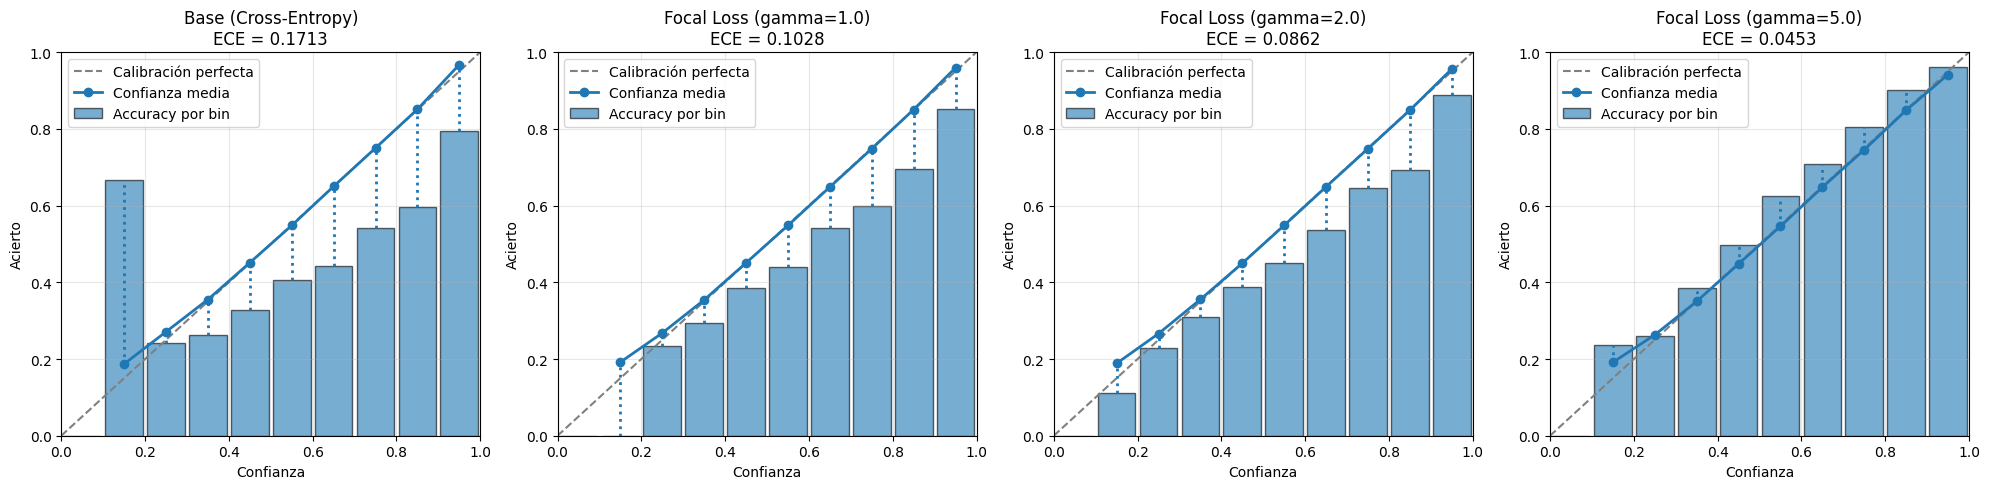

In [ ]:
fig, axes = plt.subplots(1, len(gammas) + 1, figsize=(20, 5))

# Gráfico del modelo base (CE)
reliability_diagram(test_labels, probs_test_base, title="Base (Cross-Entropy)", ax=axes[0])

# Gráficos de los modelos Focal
for i, g in enumerate(gammas):
    model = focal_models[f"Focal_gamma_{g}"]
    probs = predict_probs(model, test_images)
    reliability_diagram(test_labels, probs, title=f"Focal Loss (gamma={g})", ax=axes[i+1])

plt.tight_layout()
plt.show()

## Extensión opcional (Focal Loss + Temperature Scaling)

In [ ]:
gammas = [1.0, 2.0, 5.0]


focal_results_calibrated = {}
focal_Ts = {}

# Modelos Focal
for g in gammas:

    model_name = f"Focal_gamma_{g}"

    model = focal_models[model_name]

    # Calibración
    T_optima, nll_val = fit_temperature(model, val_images, val_labels)
    focal_Ts[model_name] = T_optima

    print(f"Temperatura óptima: {T_optima:.4f}")

    probs_test_calib = predict_tscaling(model, test_images, T_optima)

    metrics_calib = evaluate_probs(
        test_labels,
        probs_test_calib,
        prefix=f"focal_{g}_calib_"
    )

    focal_results_calibrated[model_name] = metrics_calib

    print(f"ECE calibrado: {metrics_calib[f'focal_{g}_calib_ece']:.4f}")

Temperatura óptima: 1.4550
ECE calibrado: 0.0175
Temperatura óptima: 1.3657
ECE calibrado: 0.0114
Temperatura óptima: 0.9366
ECE calibrado: 0.0274


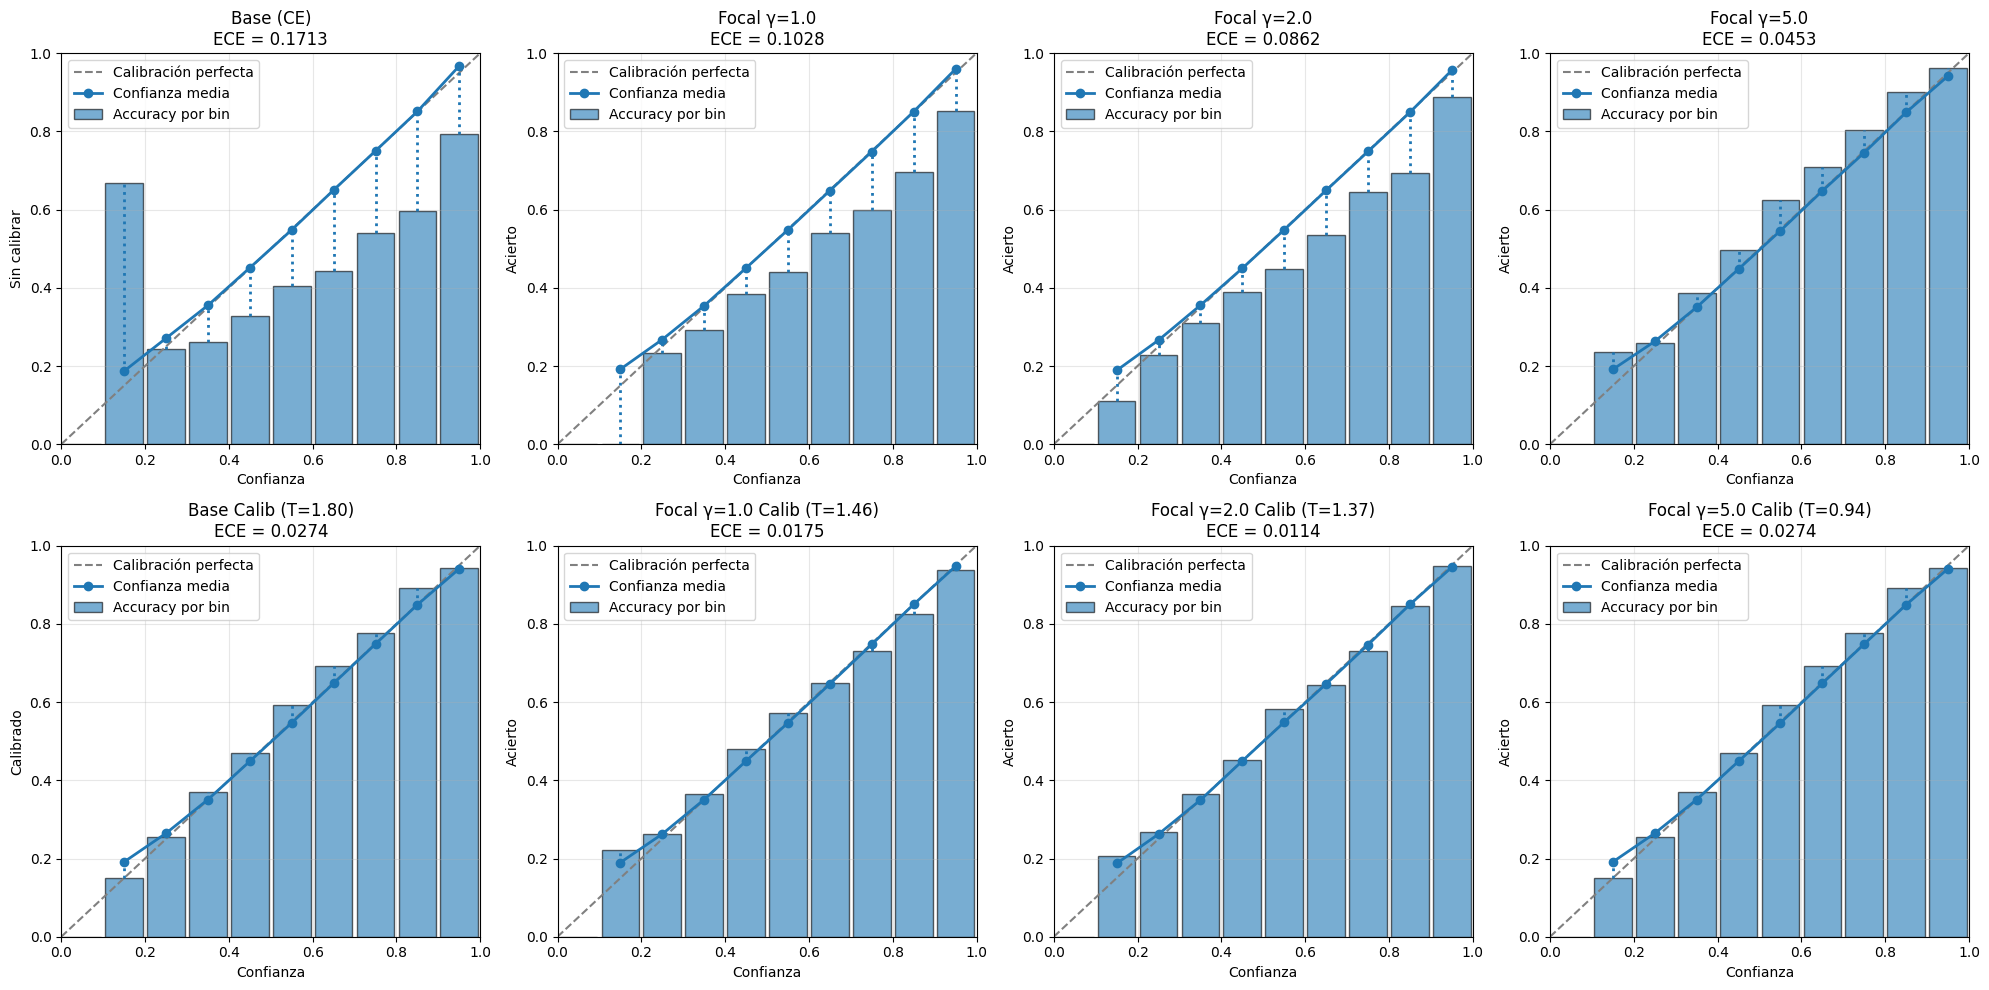

In [ ]:
fig, axes = plt.subplots(2, len(gammas) + 1, figsize=(20, 10))

# La primera fila son los modelos sin calibrar
reliability_diagram(
    test_labels,
    probs_test_base,
    title="Base (CE)",
    ax=axes[0, 0]
)

for i, g in enumerate(gammas):
    probs = predict_probs(focal_models[f"Focal_gamma_{g}"], test_images)

    reliability_diagram(
        test_labels,
        probs,
        title=f"Focal γ={g}",
        ax=axes[0, i+1]
    )

# La segunda fila son los modelos calibrados
reliability_diagram(
    test_labels,
    probs_test_calib,
    title=f"Base Calib (T={T_base:.2f})",
    ax=axes[1, 0]
)

for i, g in enumerate(gammas):
    model_name = f"Focal_gamma_{g}"
    model = focal_models[model_name]
    T = focal_Ts[model_name]

    probs_calib = predict_tscaling(model, test_images, T)

    reliability_diagram(
        test_labels,
        probs_calib,
        title=f"Focal γ={g} Calib (T={T:.2f})",
        ax=axes[1, i+1]
    )

axes[0, 0].set_ylabel("Sin calibrar")
axes[1, 0].set_ylabel("Calibrado")

plt.tight_layout()
plt.show()